In [1]:
#install micropip
import micropip
await micropip.install('seaborn')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
#loading the data set
data = pd.read_csv('Online Payment Fraud Detection.csv',encoding='unicode-escape')

In [4]:
#Checking size of dataset
data.shape

(1048575, 10)

In [5]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [6]:
data.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0
1048574,95,PAYMENT,11450.03,C1264356443,80584.95,69134.92,M677577406,0.00,0.00,0


In [7]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00


In [8]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 68.0+ MB


In [10]:
# check for missing Data
data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

After understanding the data we go for exploring relationship in the dataset

Relationships and Insights

In [11]:
# to check distinct recipients
data.nameDest.unique()

array(['M1979787155', 'M2044282225', 'C553264065', ..., 'M1355182933',
       'M1964992463', 'M677577406'], shape=(449635,), dtype=object)

In [12]:
#to check unique customers
data.nameOrig.unique()

array(['C1231006815', 'C1666544295', 'C1305486145', ..., 'C2037964975',
       'C1633237354', 'C1264356443'], shape=(1048317,), dtype=object)

In [13]:
#to check how many times customer started a transcation
data.nameOrig.value_counts()

nameOrig
C1214450722    2
C309111136     2
C1268675361    2
C720460198     2
C1109092856    2
              ..
C560131732     1
C455251560     1
C650578540     1
C1883668225    1
C1264356443    1
Name: count, Length: 1048317, dtype: int64

In [14]:
#to check jow many times a recipient got a transaction
data.nameDest.value_counts()

nameDest
C985934102     98
C1286084959    96
C1590550415    89
C248609774     88
C665576141     87
               ..
M382871047      1
M322765556      1
M1118794441     1
M1127250627     1
M677577406      1
Name: count, Length: 449635, dtype: int64

In [15]:
data.amount.max()

np.float64(10000000.0)

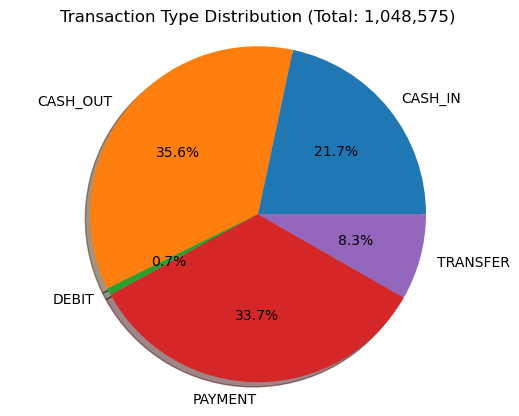

In [16]:
#Distribution of type of transaction mode
labels = data['type'].astype('category').cat.categories.tolist()
counts = data['type'].value_counts()
sizes = [counts[var_cat] for var_cat in labels]
fig1, ax1 = plt.subplots()
ax1.set_title('Transaction type Distribution')
total = sum(sizes)
ax1.set_title(f'Transaction Type Distribution (Total: {total:,})')
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True) #autopct is show the % on plot
ax1.axis('equal')
plt.show()

In [17]:
#Number of times each transaction type was carried out
data.type.value_counts()

type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

In [18]:
#Top customers and type of transaction initiated
top_ten = data.groupby('nameOrig').type.sum().sort_values(ascending=False)[:10]
top_ten

nameOrig
C24957224      TRANSFERTRANSFER
C1378765159    TRANSFERTRANSFER
C813633808     TRANSFERTRANSFER
C940075559     TRANSFERTRANSFER
C1709295811     TRANSFERPAYMENT
C196315367      TRANSFERPAYMENT
C1077087409     TRANSFERPAYMENT
C495164373      TRANSFERPAYMENT
C192628069      TRANSFERPAYMENT
C1039623203     TRANSFERPAYMENT
Name: type, dtype: object

In [19]:
#Average amount transacted
data['amount'].mean()

np.float64(158666.9755271392)

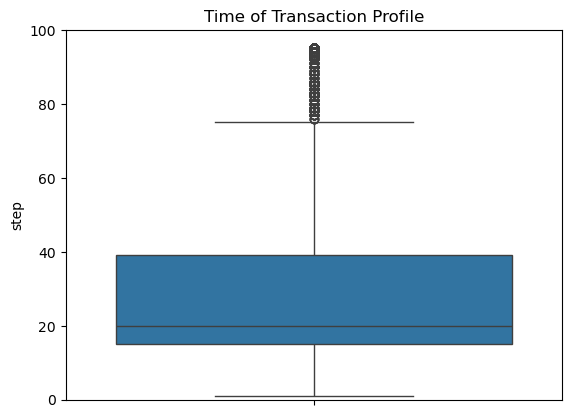

In [20]:
sns.boxplot(y=data.step)
plt.title('Time of Transaction Profile')
plt.ylim(0,100)
plt.show()

The box plot summarizes transaction timing by displaying the median, spread, and outliers of the step variable. It helps identify when most transactions occur and highlights unusually late transactions.

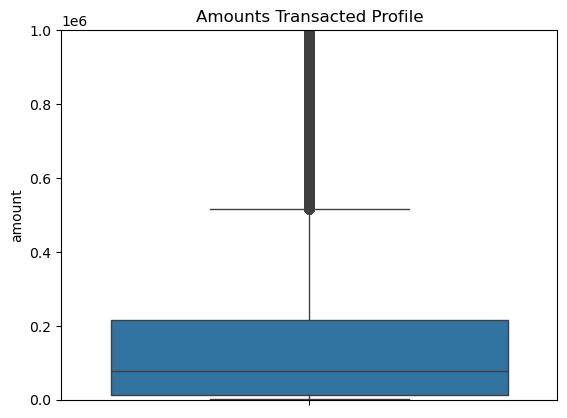

In [21]:
sns.boxplot(y=data.amount)
plt.title('Amounts Transacted Profile')
plt.ylim(0,1000000)
plt.show()

The box plot shows the spread and median of transaction amounts and highlights extreme values. The presence of high-value outliers indicates a highly skewed distribution.

Now to check fraud profile

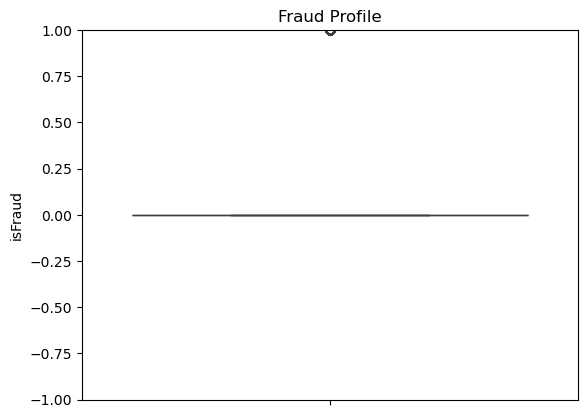

In [22]:
sns.boxplot(y=data.isFraud)
plt.title('Fraud Profile')
plt.ylim(-1,1)
plt.show()

Below is the pair plot to explore relationships between key transaction and balance variables, highlighting differences in patterns between fraudulent and non-fraudulent transactions.

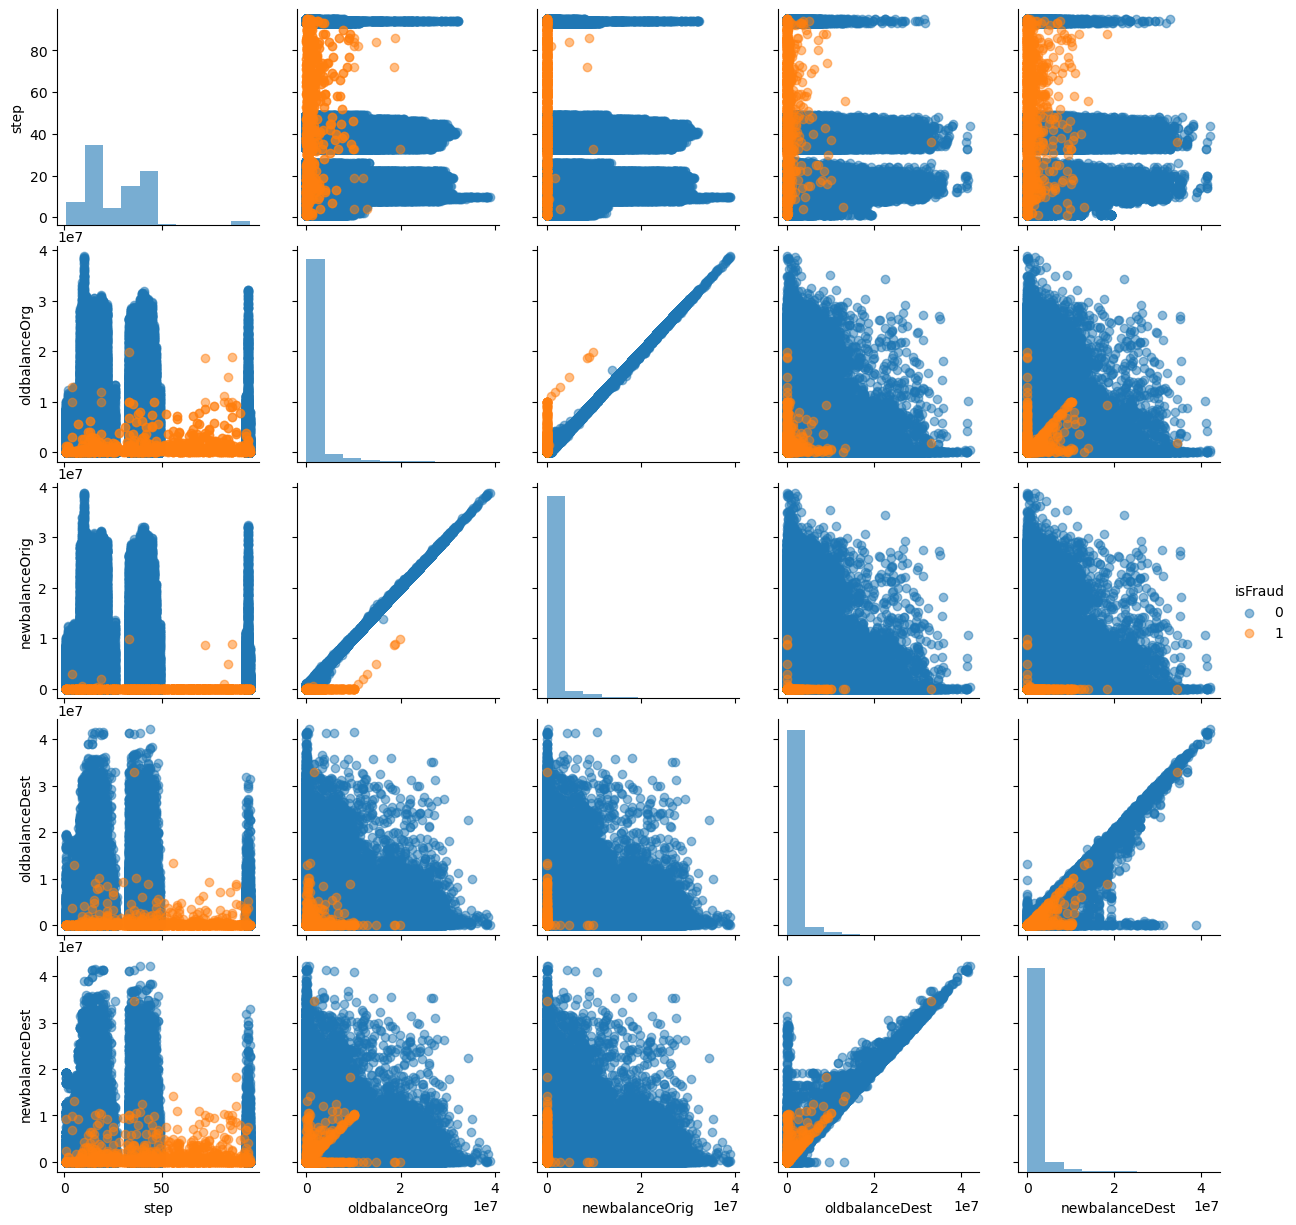

In [23]:
#Visualising the spread of fraud variables across the dataset

Online_Payment_layout = sns.PairGrid(data, vars = ['step', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], hue = 'isFraud')
Online_Payment_layout.map_diag(plt.hist, alpha = 0.6)
Online_Payment_layout.map_offdiag(plt.scatter, alpha = 0.5)
Online_Payment_layout.add_legend()

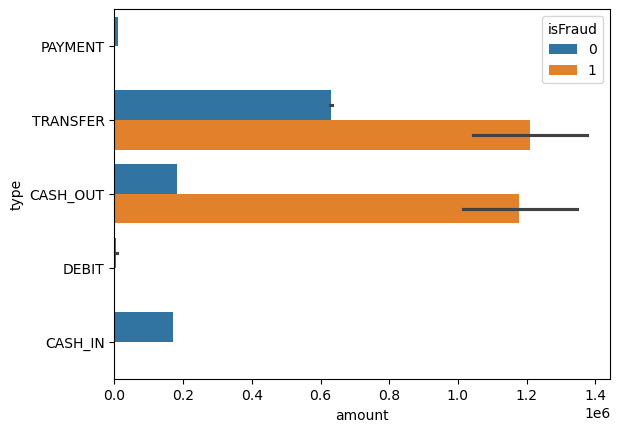

In [24]:
sns.barplot(x='amount', y='type', hue= 'isFraud', data=data)
plt.show()

(0.0, 2000000.0)

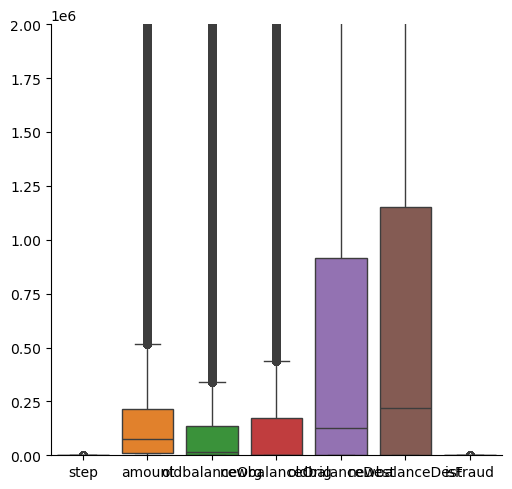

In [25]:
sns.catplot(data=data,kind='box')

plt.ylim(0,2000000)

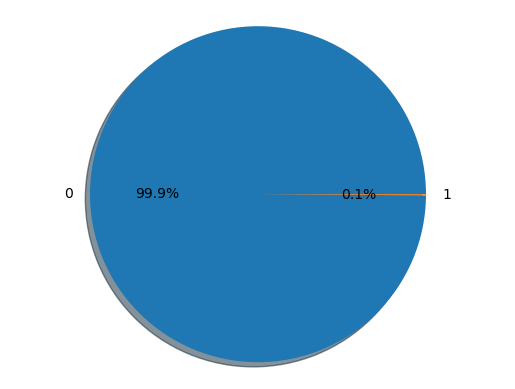

In [26]:
# Fraud Distribution

labels = data['isFraud'].astype('category').cat.categories.tolist()
counts = data['isFraud'].value_counts()
sizes = [counts[var_cat] for var_cat in labels]
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True) #autopct is show the % on plot
ax1.axis('equal')
plt.show()

In [27]:
# Sepearating Fraudulent transaction from non fraudulent

Fraudulent_Transaction = data[data.isFraud ==1]
Not_Fraudulent_Transaction = data[data.isFraud ==0]

In [28]:
print('Fraudulent Transaction: {}'.format(len(Fraudulent_Transaction)))
print('Not Fraudulent Transaction: {}'.format(len(Not_Fraudulent_Transaction)))

Fraudulent Transaction: 1142
Not Fraudulent Transaction: 1047433


In [29]:
#Understanding The statistical nature of Non Fraudulent Transactions.

Not_Fraudulent_Transaction.amount.describe()

count    1.047433e+06
mean     1.575397e+05
std      2.541883e+05
min      1.000000e-01
25%      1.213487e+04
50%      7.621497e+04
75%      2.134928e+05
max      6.419835e+06
Name: amount, dtype: float64

In [30]:
data.groupby('isFraud')[['amount', 'oldbalanceOrg', 'newbalanceOrig']].mean()

,amount,oldbalanceOrg,newbalanceOrig
isFraud,,,
0,1.575397e+05,8.736338e+05,894746.395080
1,1.192629e+06,1.218636e+06,33944.321208


Undersampling

To address class imbalance, we construct a sample dataset with a similar distribution of fraudulent and non-fraudulent transactions. This balanced dataset helps improve the model’s ability to learn fraud patterns and make more accurate predictions.
Since the objective is fraud detection, the sampling strategy is based on the number of fraudulent transactions present in the original dataset. The original data contains 1,142 fraudulent transactions, which is used as the reference for sampling.

In [31]:
Non_Fraudulent_Sample = Not_Fraudulent_Transaction.sample(n=1142)

Joining the two dataframes

In [32]:
new_dataset = pd.concat([Non_Fraudulent_Sample, Fraudulent_Transaction], axis=0)

In [33]:
new_dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
550817,21,PAYMENT,771.97,C1304539466,8009.63,7237.66,M861420175,0.00,0.00,0
24671,8,PAYMENT,9582.17,C1999358468,0.00,0.00,M2040064851,0.00,0.00,0
362131,17,PAYMENT,7061.51,C1698349214,0.00,0.00,M161904311,0.00,0.00,0
91709,10,PAYMENT,41414.68,C354852608,2030.00,0.00,M478143468,0.00,0.00,0
418670,18,CASH_OUT,139586.67,C1266521946,0.00,0.00,C425902101,1006586.45,1146173.12,0


In [34]:
new_dataset.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
1047888,95,CASH_OUT,56745.14,C526144262,56745.14,0.0,C79051264,51433.88,108179.02,1
1048221,95,TRANSFER,33676.59,C732111322,33676.59,0.0,C1140210295,0.00,0.00,1
1048222,95,CASH_OUT,33676.59,C1000086512,33676.59,0.0,C1759363094,0.00,33676.59,1
1048323,95,TRANSFER,87999.25,C927181710,87999.25,0.0,C757947873,0.00,0.00,1
1048324,95,CASH_OUT,87999.25,C409531429,87999.25,0.0,C1827219533,0.00,87999.25,1


In [35]:
new_dataset['isFraud'].value_counts()

isFraud
0    1142
1    1142
Name: count, dtype: int64

In [39]:
new_dataset.shape

(2284, 10)

In [40]:
#Checking to see if the new dataset we obtained is a good i.e does not deviate significantly from our original dataset
new_dataset.groupby('isFraud')[['amount', 'oldbalanceOrg', 'newbalanceOrig','oldbalanceDest','newbalanceDest']].mean()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,,
0,1.756821e+05,8.453322e+05,866762.835630,994004.445105,1.128777e+06
1,1.192629e+06,1.218636e+06,33944.321208,452866.124527,1.077940e+06


The newly created dataset is well-balanced, resolving the class imbalance issue. This dataset can now be used for feature selection, target definition, and model training.

Feature Engineering

ONE-HOT ENCODING

To train and test our machine learning model, we select features (columns) from our dataset
Because our dataset contains categorial values ('nameOrig', 'nameDest'). it becomes necessary to convert them into binary format which can be readily used by or Machine learning model.

In [41]:
# One-hot Encoding.
#Importing library

from sklearn.preprocessing import OneHotEncoder

In [43]:
#creating instance of one-hot-encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop=None,)

In [44]:
#perform one-hot encoding on 'type' column 
encoder_df =  pd.get_dummies(new_dataset, columns=['type','nameOrig','nameDest'], prefix=['type','nameOrig','nameDest'])


In [45]:
encoder_df

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,...,nameDest_M954703496,nameDest_M957557227,nameDest_M962298661,nameDest_M969917202,nameDest_M983101991,nameDest_M988912970,nameDest_M990212498,nameDest_M992005724,nameDest_M993507319,nameDest_M994092124
550817,21,771.97,8009.63,7237.66,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24671,8,9582.17,0.00,0.00,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
362131,17,7061.51,0.00,0.00,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
91709,10,41414.68,2030.00,0.00,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
418670,18,139586.67,0.00,0.00,1006586.45,1146173.12,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1047888,95,56745.14,56745.14,0.00,51433.88,108179.02,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048221,95,33676.59,33676.59,0.00,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1048222,95,33676.59,33676.59,0.00,0.00,33676.59,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048323,95,87999.25,87999.25,0.00,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [46]:
encoder_df.shape

(2284, 4554)

In [47]:
# Check result of one-hot encoding
encoder_df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,...,nameDest_M954703496,nameDest_M957557227,nameDest_M962298661,nameDest_M969917202,nameDest_M983101991,nameDest_M988912970,nameDest_M990212498,nameDest_M992005724,nameDest_M993507319,nameDest_M994092124
550817,21,771.97,8009.63,7237.66,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24671,8,9582.17,0.00,0.00,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
362131,17,7061.51,0.00,0.00,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
91709,10,41414.68,2030.00,0.00,0.00,0.00,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
418670,18,139586.67,0.00,0.00,1006586.45,1146173.12,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [48]:
encoder_df.tail()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,...,nameDest_M954703496,nameDest_M957557227,nameDest_M962298661,nameDest_M969917202,nameDest_M983101991,nameDest_M988912970,nameDest_M990212498,nameDest_M992005724,nameDest_M993507319,nameDest_M994092124
1047888,95,56745.14,56745.14,0.0,51433.88,108179.02,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048221,95,33676.59,33676.59,0.0,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1048222,95,33676.59,33676.59,0.0,0.00,33676.59,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1048323,95,87999.25,87999.25,0.0,0.00,0.00,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1048324,95,87999.25,87999.25,0.0,0.00,87999.25,1,False,True,False,...,False,False,False,False,False,False,False,False,False,False


Target, Feature Split

Target Selection

'isFraud' column selected as Target (Y)

In [49]:
Y = encoder_df['isFraud']

In [50]:
features = encoder_df.drop('isFraud', axis=1)

In [51]:
X = features

In [52]:
Y.head()

550817    0
24671     0
362131    0
91709     0
418670    0
Name: isFraud, dtype: int64

In [53]:
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,...,nameDest_M954703496,nameDest_M957557227,nameDest_M962298661,nameDest_M969917202,nameDest_M983101991,nameDest_M988912970,nameDest_M990212498,nameDest_M992005724,nameDest_M993507319,nameDest_M994092124
550817,21,771.97,8009.63,7237.66,0.00,0.00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
24671,8,9582.17,0.00,0.00,0.00,0.00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
362131,17,7061.51,0.00,0.00,0.00,0.00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
91709,10,41414.68,2030.00,0.00,0.00,0.00,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
418670,18,139586.67,0.00,0.00,1006586.45,1146173.12,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
#create X_train, X_test, Y_train, Y_test
# using test_size of 20%

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, stratify=Y, random_state=2)

In [56]:
print('\n',X_train.head(2))

print('\n',X_test.head(2))

print('\n',Y_train.head(2))

print('\n',Y_test.head(2))


          step     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
1030484    67  106460.70      106460.70            0.00      1414263.15   
944954     43  331488.95     2341030.82      2672519.77       868937.16   

         newbalanceDest  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
1030484      1520723.84         False           True       False   
944954        537448.22          True          False       False   

         type_PAYMENT  ...  nameDest_M954703496  nameDest_M957557227  \
1030484         False  ...                False                False   
944954          False  ...                False                False   

         nameDest_M962298661  nameDest_M969917202  nameDest_M983101991  \
1030484                False                False                False   
944954                 False                False                False   

         nameDest_M988912970  nameDest_M990212498  nameDest_M992005724  \
1030484                False                False    

Training our classification model with a Logistic Regression classifier

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
model = LogisticRegression()

In [59]:
#Training model with Training data
model.fit(X_train, Y_train)

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
model_pred = model.predict(X_test)

In [61]:
# Obtain model probabilities
probs = model.predict_proba(X_test)

Logistec Regression Model Evaluation

In [62]:
#importing the methods
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_recall_curve, average_precision_score, roc_auc_score


In [63]:
print('\nClassification Report:')
print(classification_report(Y_test, model_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       229
           1       0.92      0.90      0.91       228

    accuracy                           0.91       457
   macro avg       0.91      0.91      0.91       457
weighted avg       0.91      0.91      0.91       457



In [64]:
# check True Negatives/Positives, False Negatives/Positives
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Negative(0) ', 'Predicted Positive(1)'], 
             index=['Actually Negative(0)', 'Actually Positive(1)'])

,Predicted Negative(0),Predicted Positive(1)
Actually Negative(0),212,17
Actually Positive(1),23,205


In [65]:
# Print confusion matrix using predictions in context 
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Not Fraud(0) ', 'Predicted Fraud(1)'], 
             index=['Actually Not Fraud(0)', 'Actually Fraud(1)'])

,Predicted Not Fraud(0),Predicted Fraud(1)
Actually Not Fraud(0),212,17
Actually Fraud(1),23,205


In [66]:
# ACCURACY SCORE
print('Accuracy:',accuracy_score(Y_test, model_pred))

Accuracy: 0.912472647702407


Our Logistic regression model indicates 91.24% accuracy

In [67]:
# Calculate average precision and the P-R curve
average_precision = average_precision_score(Y_test, model_pred)
average_precision

0.8805992881053344

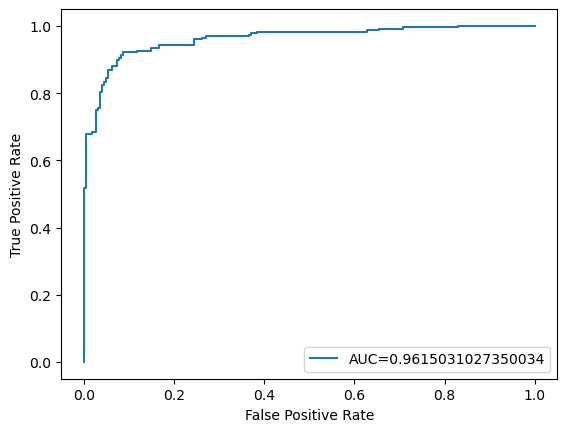

In [68]:
#define metrics
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(Y_test,  y_pred_proba)
auc = metrics.roc_auc_score(Y_test, y_pred_proba)


#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [69]:
print('AUC Score:')
print(roc_auc_score(Y_test, probs[:,1]))

AUC Score:
0.9615031027350034


The ROC (Receiver Operating Characteristic) curve is a performance metric used to evaluate classification models. It plots the true positive rate against the false positive rate, providing insight into the model’s ability to distinguish between classes. The Area Under the Curve (AUC) summarizes this performance, where a higher value indicates better class separation.
An AUC score of 0.97 indicates that the model has a 97% probability of correctly ranking a randomly chosen positive instance higher than a negative one, demonstrating strong discriminative performance. As a result, AUC is often more informative than accuracy, especially for imbalanced datasets.

Training with Random Forest Classifier

In [71]:
from sklearn.ensemble import RandomForestClassifier

In [72]:
# Define the model as the random forest
model = RandomForestClassifier(random_state=5, n_estimators=20)

In [73]:
model.fit(X_train,Y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
model_pred = model.predict(X_test)

In [75]:
# Obtain model probabilities
probs = model.predict_proba(X_test)

Random Forest Model Evaluation

In [76]:
#importing the methods
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_recall_curve, average_precision_score, roc_auc_score


In [77]:
# Print classification report using predictions
print('Classification_Report:\n',classification_report(Y_test, model_pred))

Classification_Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       229
           1       0.98      0.95      0.96       228

    accuracy                           0.96       457
   macro avg       0.97      0.96      0.96       457
weighted avg       0.97      0.96      0.96       457



In [78]:
# Print confusion matrix using predictions
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Negative(0) ', 'Predicted Positive(1)'], 
             index=['Actually Negative(0)', 'Actually Positive(1)'])

,Predicted Negative(0),Predicted Positive(1)
Actually Negative(0),224,5
Actually Positive(1),11,217


In [79]:
# Print confusion matrix using predictions in Context
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Not Fraud(0) ', 'Predicted Fraud(1)'], 
             index=['Actually Not Fraud(0)', 'Actually Fraud(1)'])

,Predicted Not Fraud(0),Predicted Fraud(1)
Actually Not Fraud(0),224,5
Actually Fraud(1),11,217


In [80]:
# Print confusion matrix using predictions in Context
pd.DataFrame(confusion_matrix(Y_test, model_pred), 
             columns=['Predicted Not Fraud(0) ', 'Predicted Fraud(1)'], 
             index=['Actually Not Fraud(0)', 'Actually Fraud(1)'])

,Predicted Not Fraud(0),Predicted Fraud(1)
Actually Not Fraud(0),224,5
Actually Fraud(1),11,217


In [81]:
# ACCURACY SCORE
print('Accuracy:',accuracy_score(Y_test, model_pred))

Accuracy: 0.9649890590809628


In [82]:
# Calculate average precision and the P-R curve
average_precision = average_precision_score(Y_test, model_pred)
average_precision

0.9543884982529459

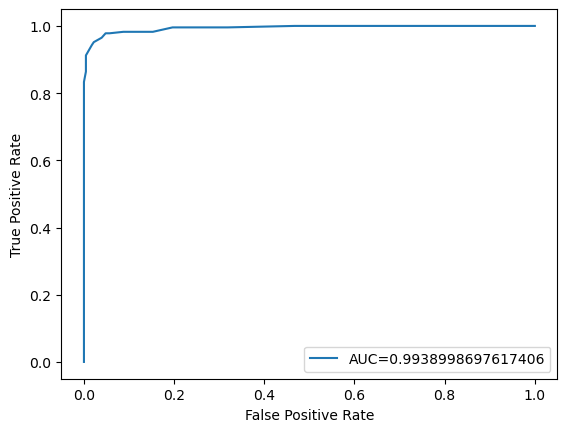

In [83]:
#define metrics
y_pred_proba = model.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(Y_test,  y_pred_proba)
auc = metrics.roc_auc_score(Y_test, y_pred_proba)


#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

In [84]:
# Print ROC_AUC score using probabilities
print('AUC Score:')
print(roc_auc_score(Y_test, probs[:, 1]))

AUC Score:
0.9938998697617406


An AUC score of 0.99 suggests that our Random Forest Model is almost perfect with 99% correct Predictions.